### Visión por computadora - Trabajo práctico 1

Docente: Ing. Maxim Dorogov

Carrera de Especialización en Inteligencia Artificial  
Laboratorio de Sistemas Embebidos  
Facultad de Ingeniería de la Universidad de Buenos Aires  


Alumnos:  
- Francisco Julio Facchini Strohmayer  
- Elian Pinzas

### **Parte 1 (imágenes en /white_patch)**

1- Implementar el algoritmo White patch para librarnos de las diferencias de color de iluminación.  

In [4]:
%matplotlib inline
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

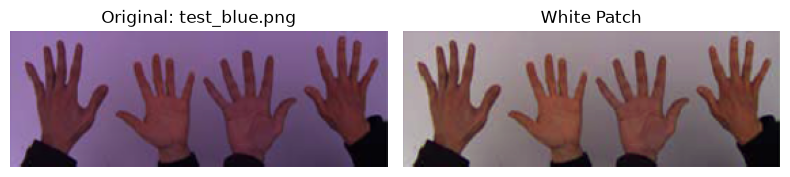

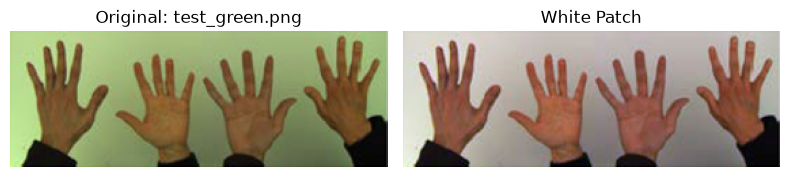

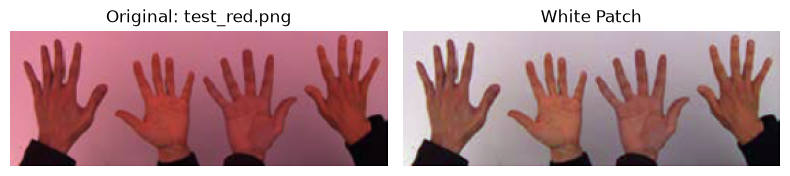

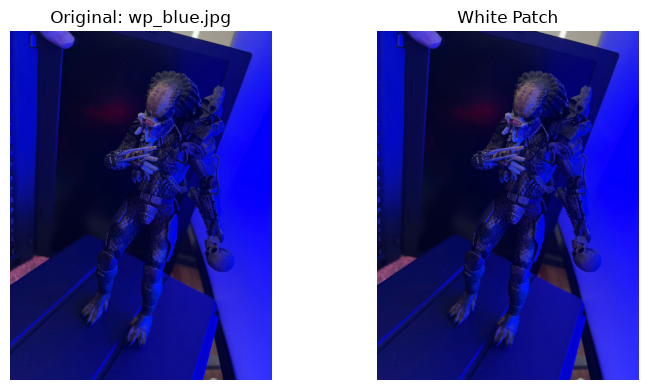

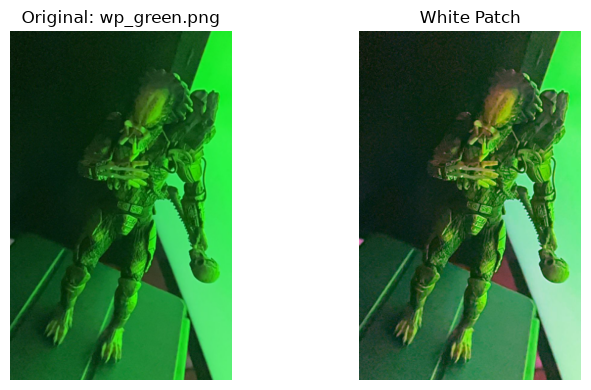

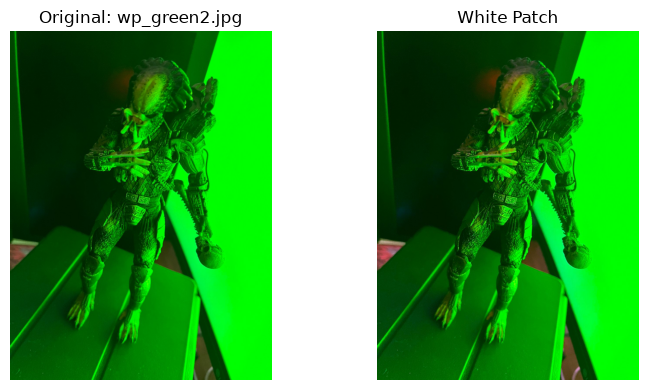

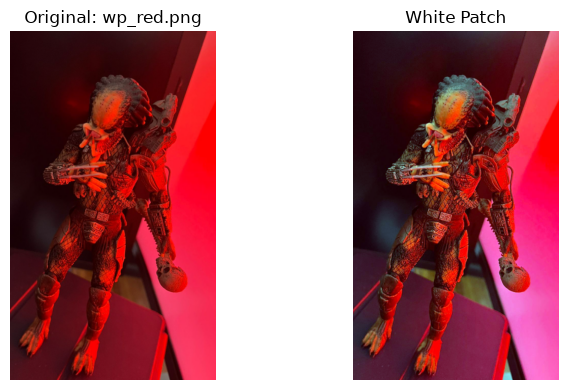

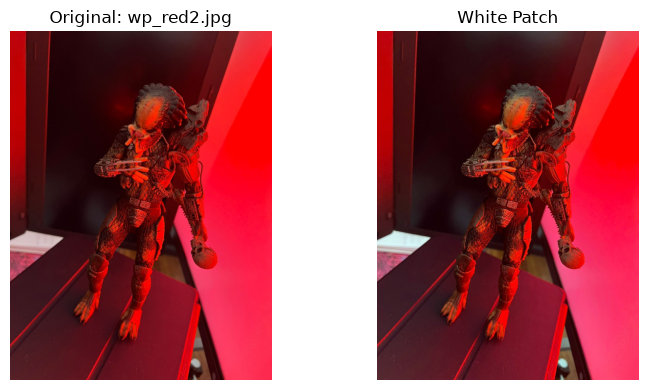

In [7]:
input_folder = "white_patch"
archivos = [
    "test_blue.png",
    "test_green.png",
    "test_red.png",
    "wp_blue.jpg",
    "wp_green.png",
    "wp_green2.jpg",
    "wp_red.png",
    "wp_red2.jpg"
]

def white_patch_algorithm(image):
    img_float = image.astype(np.float32)
    max_vals = np.max(img_float, axis=(0, 1))
    max_vals[max_vals == 0] = 1.0  # Evitar división por cero
    
    max_global = np.max(max_vals)
    img_corrected = img_float * (max_global / max_vals)
    
    return np.clip(img_corrected, 0, 255).astype(np.uint8)

for nombre_archivo in archivos:
    ruta_imagen = os.path.join(input_folder, nombre_archivo)
    
    # Cargar imagen con OpenCV (lee en BGR)
    img_bgr = cv2.imread(ruta_imagen)
    
    if img_bgr is None:
        print(f"No se pudo cargar: {nombre_archivo}")
        continue
        
    # Aplicar White Patch
    img_procesada_bgr = white_patch_algorithm(img_bgr)
    
    # Convertir de BGR a RGB para que Matplotlib las muestre con los colores correctos
    img_original_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_procesada_rgb = cv2.cvtColor(img_procesada_bgr, cv2.COLOR_BGR2RGB)
    
    # Graficar la comparación lado a lado
    plt.figure(figsize=(8, 4))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img_original_rgb)
    plt.title(f"Original: {nombre_archivo}")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(img_procesada_rgb)
    plt.title("White Patch")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

2- Mostrar los resultados obtenidos y analizar las posibles fallas (si es que las hay) en el caso de White patch.

**1. Resultados con éxito**: test_blue.png, test_green.png, test_red.png: en estas imágenes el algoritmo logró eliminar con gran éxito la componente de color en cada caso (azul, verde y rojo). En todas se observa un fondo de color claro y objetos en primer plano.

**2. Resultados con cambios (pero sin éxito)**: wp_green.png y wp_red.png: se observa en estas imágenes un cierto cambio en determinada región. Sin embargo, en el resultado general el algoritmo no fue capaz de eliminar la componente de iluminación

**3. Resultados con fracaso total**: wp_blue.jpg, wp_red2.jpg, wp_green2.jpg: en estas imágenes, el algoritmo no logró cambiar prácticamente nada.

Conclusiones en general:  
- El algoritmo asume que el píxel máximo absoluto de cada canal corresponde a una superficie blanca iluminada. En algunas de estas imágenes, los reflejos de la luz de colores sobre las figuras o los puntos de saturación actúan como máximos absolutos engañosos. Al tomar ese valor como referencia "blanca", el factor de escala no logra corregir la dominante ambiental general.

- En escenarios oscuros o con colores muy fuertes, ningún objeto de la escena refleja los tres canales de manera equitativa. Como tal, el máximo de cada canal se fija a partir de reflejos arbitrarios del color de la luz, provocando que el algoritmo falle.

**Nota (FF):** comparando `wp_green.png`/`wp_red.png` (versiones recortadas) contra `wp_green2.jpg`/`wp_red2.jpg` (foto completa de la misma escena), se observa que el resultado de White Patch cambia según qué parte de la escena queda dentro del recorte: como el algoritmo calcula el máximo sobre toda la imagen, incluir o excluir una zona de brillo cambia el factor de escala y, por lo tanto, cuánto se corrige el color..

#### Comprarativa variante de fórmula (FF)

La implementación de arriba escala los tres canales en base al máximo **entre los tres**
(`max_global`). La diapositiva de la cátedra plantea la versión "White Patch original", que
escala **cada canal por separado** hasta que su propio máximo llegue a 255:

$$(R,G,B) \;\rightarrow\; \left(\frac{255}{R_{max}}R,\; \frac{255}{G_{max}}G,\; \frac{255}{B_{max}}B\right)$$

Se compararon ambas fórmulas sobre las 8 imágenes: en 6 de las 8 dan un resultado
prácticamente idéntico, porque esas fotos ya tienen al menos un canal saturado en 255 en la
imagen original (ahí `max_global` coincide con 255 y las dos versiones se equivalen). La única
diferencia visible aparece en `test_blue.png`, la única imagen sin ningún canal saturado:


Diferencia media entre las dos fórmulas en test_blue.png: 29.8
Brillo medio - versión max_global: 108.4 | versión cada canal a 255: 138.2


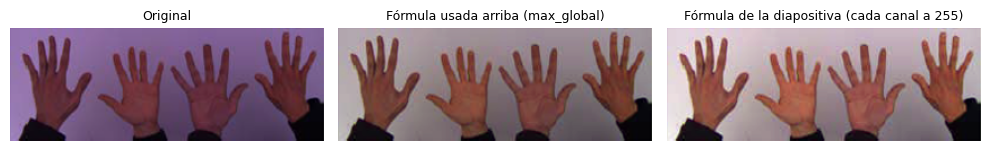

In [100]:
def white_patch_original(image):
    """Versión de la diapositiva: cada canal se escala por separado a 255."""
    img = image.astype(np.float64)
    max_c = img.max(axis=(0, 1))
    max_c[max_c == 0] = 1.0
    return np.clip(img * (255.0 / max_c), 0, 255).astype(np.uint8)


img_test = cv2.imread("white_patch/test_blue.png")
corr_global = white_patch_algorithm(img_test)   # fórmula ya usada arriba (max entre canales)
corr_original = white_patch_original(img_test)  # fórmula de la diapositiva (cada canal a 255)

diff = np.abs(corr_global.astype(int) - corr_original.astype(int))
print(f"Diferencia media entre las dos fórmulas en test_blue.png: {diff.mean():.1f}")
print(f"Brillo medio - versión max_global: {corr_global.mean():.1f} | versión cada canal a 255: {corr_original.mean():.1f}")

plt.figure(figsize=(10, 3))
for i, (im, titulo) in enumerate([
    (img_test, "Original"),
    (corr_global, "Fórmula usada arriba (max_global)"),
    (corr_original, "Fórmula de la diapositiva (cada canal a 255)"),
]):
    plt.subplot(1, 3, i + 1)
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    plt.title(titulo, fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()


Con la fórmula de la diapositiva la imagen queda con más brillo (se fuerza el punto más
claro a blanco puro), mientras que la versión usada arriba deja el resultado un poco más tenue
porque no llega a estirar el brillo hasta 255. En el resto de las imágenes ambas fórmulas dan
prácticamente el mismo resultado, así que no cambia ninguna de las conclusiones de más arriba,
se deja documentada la diferencia como una variante válida más que como una corrección.


### **Parte 2**

1- Para las imágenes img1_tp.png y img2_tp.png leerlas con OpenCV en escala de grises y visualizarlas.  

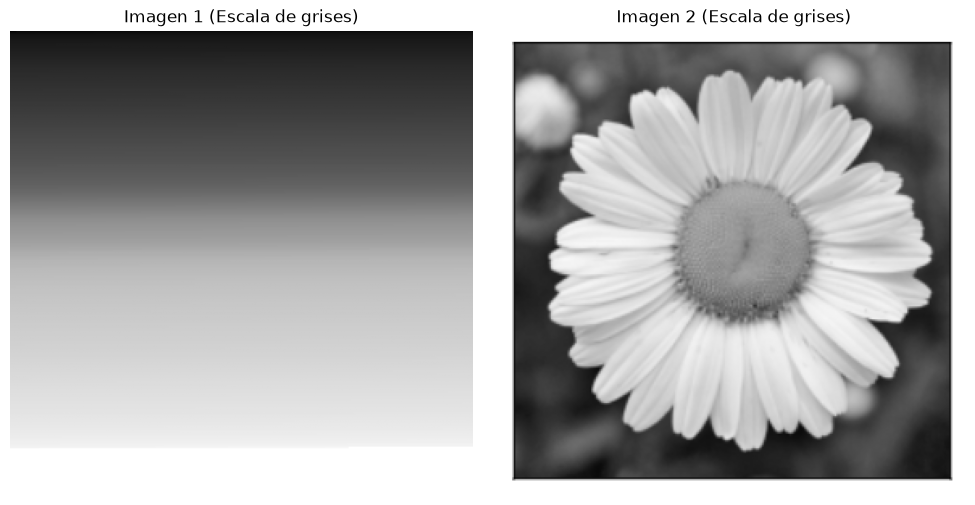

In [8]:
img1_path = "img1_tp.png"
img2_path = "img2_tp.png"

img1_gray = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
img2_gray = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)

if img1_gray is None or img2_gray is None:
    print("Error: No se pudieron cargar una o ambas imágenes")
else:
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img1_gray, cmap='gray')
    plt.title("Imagen 1 (Escala de grises)")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(img2_gray, cmap='gray')
    plt.title("Imagen 2 (Escala de grises)")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

2- Elija el número de bins que crea conveniente y grafique su histograma, compare los histogramas entre sí. Explicar lo que se observa, si tuviera que entrenar un modelo de clasificación/detección de imágenes, ¿considera que puede ser de utilidad tomar como 'features' a los histogramas?

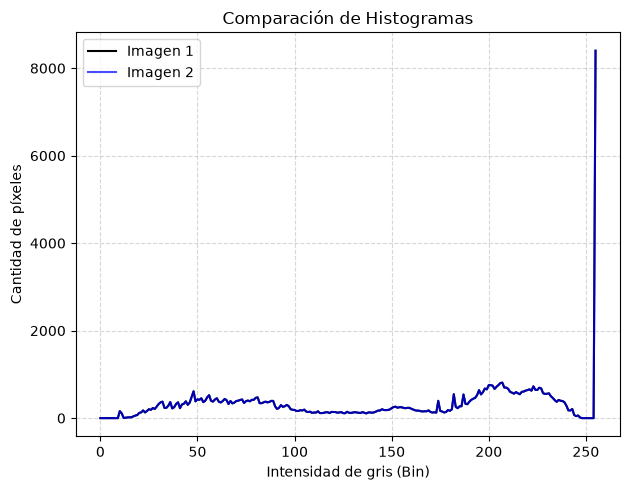

In [11]:
num_bins = 256

# Calcular los histogramas
hist1 = cv2.calcHist([img1_gray], [0], None, [num_bins], [0, 256])
hist2 = cv2.calcHist([img2_gray], [0], None, [num_bins], [0, 256])

# Graficar y comparar los histogramas
plt.figure(figsize=(12, 5))

# Gráfico de las imágenes
plt.subplot(1, 2, 1)
plt.plot(hist1, color='black', label='Imagen 1')
plt.plot(hist2, color='blue', label='Imagen 2', alpha=0.7)
plt.title("Comparación de Histogramas")
plt.xlabel("Intensidad de gris (Bin)")
plt.ylabel("Cantidad de píxeles")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [101]:
# Verificación explícita: ¿son realmente iguales los histogramas?
print("¿hist1 y hist2 son exactamente iguales?", np.array_equal(hist1, hist2))
print("Diferencia máxima entre ambos histogramas:", np.abs(hist1 - hist2).max())
print("¿Mismo conjunto de valores de gris, solo reordenados espacialmente?",
      np.array_equal(np.sort(img1_gray.flatten()), np.sort(img2_gray.flatten())))


¿hist1 y hist2 son exactamente iguales? True
Diferencia máxima entre ambos histogramas: 0.0
¿Mismo conjunto de valores de gris, solo reordenados espacialmente? True


**Qué se observa:** el gráfico superpuesto de arriba en realidad muestra una sola curva
visible porque **las dos son exactamente iguales**, no solo parecidas. La celda anterior lo
confirma numéricamente: `img1_tp.png` (el degradé) e `img2_tp.png` (la foto de la flor)
contienen el mismo conjunto de valores de gris, solo distribuidos en posiciones distintas
dentro de la imagen. Son dos imágenes con contenido visual completamente distinto que colapsan
al mismo histograma.

**¿Sirven los histogramas como *features* para clasificación/detección?** Este caso es la
mejor evidencia de que **no alcanzan por sí solos**: el histograma es invariante a la posición
espacial de los valores de intensidad, así que dos imágenes con estructura, bordes y contenido
completamente distintos pueden volverse indistinguibles al reducirlas a su histograma. Como
descriptor complementario puede aportar señal barata sobre brillo global o contraste, pero para
un problema real de clasificación/detección de imágenes con estructura hace falta algo que
capture información espacial (bordes, texturas, descriptores locales, o las activaciones de una
red convolucional), el histograma de grises solo no es suficiente.
